# TLS-derived FSP tree-model parameters from archived QSM outputs
**Paper:** Bekkers V., Evers J., Lau A. (2024) *Improving the 3D representation of plant architecture and parameterization efficiency of functional–structural tree models using terrestrial LiDAR data.* AoB PLANTS 17(2): plae071, [doi:10.1093/aobpla/plae071](https://doi.org/10.1093/aobpla/plae071)

**Data & author code:** 4TU Research Data, [doi:10.4121/2b7e832f-12e9-4d0e-92e2-5aef9bcf9142.v1](https://data.4tu.nl/datasets/2b7e832f-12e9-4d0e-92e2-5aef9bcf9142/versions/1) (CC BY 4.0)

## Scope (partial demonstration — executed)
This notebook re-runs the paper's **parameter-derivation** and **height/DBH accuracy** steps *using the authors' own Python logic* on the archived QSM outputs:

1. TLS-derived branch angles (1st/2nd order) and internode lengths (trunk, 1st-order branches) per Guyana species, from `branch_data_*` / `cyl_data_*` QSM output (authors' `ReCalc_for_Petter.py` logic).
2. Scots pine (Loobos) branch angles and normal-distribution fits.
3. Height and DBH RMSE / relative RMSE / R² against the deposited field inventory (authors' `Acc_QSM_Guyana.py` logic).

**Not included (out of scope / not reproducible here):** MATLAB TreeQSM fitting from raw point clouds, LeWoS wood–leaf separation and manual CloudCompare correction, the GroIMP FSP model runs, and the branch-angle/internode RMSE of paper Table 4 — those require CloudCompare-measured comparison CSVs that are **not** part of the deposit (they are `FILL_IN_FILE_PATH` placeholders in the authors' scripts). The paper's Table 4 height (2.97 %) and DBH (17.24 %) relative-RMSE values for the tropical trees are our reference points.

**Adaptations (AI-assisted, documented):** the deposited scripts contain `FILL_IN_FILE_PATH` placeholders and expect a `cleaned_QSM_results_Guyana/{tree}/OptQSM/` folder layout, while the deposit stores files flat; the tree→species mapping CSV is not in the deposit, so the mapping is rebuilt from `Field_Inventory_Guyana.xlsx` (column `CommName`). The authors' numerical operations are preserved. The authors did not provide this Colab implementation; untested behaviour is not guaranteed.

**日本語:** このノートブックは、論文の「TLS-QSM 出力から FSP モデル用の構造パラメータ（枝角・節間長）を導出する処理」と「高さ・DBH の精度検証（RMSE・相対 RMSE・R²）」を、著者自身の Python スクリプトの計算手順に従って再実行するものです（部分的なデモ）。GroIMP による FSP モデル実行や MATLAB TreeQSM フィッティングは対象外です。実行は CPU のみで数分未満です。ランタイムは **CPU** を選択し、最初から最後まで実行してください。

## 1 · Environment setup
Only pandas/numpy/scipy/matplotlib are needed (preinstalled on Colab) plus `openpyxl` to read the field-inventory Excel file. No GPU is used anywhere in this analysis.

**日本語:** 必要なのは pandas/numpy/scipy/matplotlib（Colab に同梱）と Excel 読み込み用の openpyxl のみです。GPU は不要です。

In [ ]:
%pip install -q openpyxl
import pandas as pd, numpy as np, scipy, matplotlib, openpyxl, sys, hashlib, urllib.request, os
print("python", sys.version.split()[0])
for m in (pd, np, scipy, matplotlib):
    print(m.__name__, m.__version__)

python 3.13.15
pandas 2.2.3
numpy 2.1.3
scipy 1.16.3
matplotlib 3.10.0


## 2 · Download the pinned deposit files (Colab-only)
We fetch only the archived QSM output tables (`branch_data_*`, `cyl_data_*`, `tree_data_*`) and the field inventory `Field_Inventory_Guyana.xlsx` (~3.3 MB total) from the pinned version DOI `10.4121/2b7e832f-12e9-4d0e-92e2-5aef9bcf9142.v1`. Every file is verified against the MD5 recorded in the 4TU file listing. The large segmented point clouds in the deposit (≈1.6 GB) are **not** needed for this analysis and are not downloaded.

**日本語:** 4TU リポジトリの固定バージョンから、解析に必要な QSM 出力表と野帳（Excel）のみ（合計約 3.3 MB）をダウンロードし、MD5 を検証します。大きな点群ファイルは不要のため取得しません。

In [ ]:
DATASET_UUID = "2b7e832f-12e9-4d0e-92e2-5aef9bcf9142"
# {path: [file_uuid, size_bytes, md5]} from the 4TU version-1 file listing (retrieved 2026-10-02)
MANIFEST = {
"branch_data_100_09_noreg.txt": [
"5a690628-1f87-48db-a12c-eb6b12fc1453",
6424,
"e1cc91f996a303a99a5dadfd871c2b47"
],
"branch_data_100_10_noreg.txt": [
"d4ca5ee1-e627-4cdc-a2fc-352809cbea5c",
9290,
"30400248bf40037fafae3502253a596b"
],
"branch_data_100_13_noreg.txt": [
"89f8fd44-ee49-4daa-a075-1b8f5b22f0f5",
9515,
"d99702800ea1175a3a65476573c297ae"
],
"branch_data_100_14_noreg.txt": [
"059fb2bd-6bce-48c5-9b01-73e73a614c0f",
3371,
"5a06cd78794834e0b1816b343ae615be"
],
"branch_data_100_15_noreg.txt": [
"82446c26-aef4-4681-9f5a-b08d94c5f6fc",
1610,
"4c7d4f20a40bb9745c2bb393d8748b2c"
],
"branch_data_20_01_noreg.txt": [
"b3c63db4-dd52-44b5-baba-61f83e6657a4",
1209,
"657ab3429ebfd981351aa0c972c9b344"
],
"branch_data_20_09_noreg.txt": [
"f8d4075d-594a-4fca-8f12-92eb5dd80f55",
1027,
"aeb32701a0a9e326e11127d27472c708"
],
"branch_data_20_21_noreg.txt": [
"98c87283-c065-4836-b8c1-13ae00825386",
1824,
"b09a24e82b9b8c2f50ba3b6a378ae988"
],
"branch_data_20_29_noreg.txt": [
"61cdac81-2546-45cb-906a-5658ea1940c7",
2122,
"04d5d571ac97c2a769d04202c049c158"
],
"branch_data_40_01_noreg.txt": [
"949b7c61-1936-47f8-9087-0bc6ef38b2bc",
1713,
"8b67bd2de41b05b945fc89a5462de456"
],
"branch_data_40_04_noreg.txt": [
"ec6661b7-d1d2-4eb1-9a1a-11f4a426212a",
880,
"03ff12d58ef3cf84a173991544e0fe7c"
],
"branch_data_40_07_noreg.txt": [
"b198c3a7-73a6-4b32-a58e-0bdd9c4ceb21",
381,
"2a6c6ea41448b6e0f0e032dd9fe4189f"
],
"branch_data_40_12_noreg.txt": [
"67e6fa8c-2090-4717-9e8e-2cb76b28c0b0",
3701,
"61ad307ed72b17def12ff36273ef47e1"
],
"branch_data_40_13_noreg.txt": [
"949ea0fa-42bf-487b-b817-26a9c8d46789",
2580,
"e6283637e8c8ad3c46b833919a811889"
],
"branch_data_40_19_noreg.txt": [
"5bfe8212-a6e5-42c1-855c-07995f90a5d5",
1239,
"8a55701a19dd4836b16aaa87c355d614"
],
"branch_data_40_22_noreg.txt": [
"226cea24-0724-42be-a4c5-91f8f8bab084",
2637,
"52e59689244cadcf81a4f711c12d736f"
],
"branch_data_40_23_noreg.txt": [
"199a3149-bb78-4c54-90cd-ae66b1e174df",
2219,
"ca83f50cf7c97830731d223df3136346"
],
"branch_data_60_01_noreg.txt": [
"21a154ae-bad2-415a-8f10-39b46a8f592c",
1776,
"82f35de8ead7e460dd5ace7056cf9103"
],
"branch_data_60_03_noreg.txt": [
"b1ea5240-b33a-4cff-8f12-1c17fefb8caa",
2205,
"feea95ecf5dd6c9731687f54e3eecb72"
],
"branch_data_60_12_noreg.txt": [
"ae992981-ce0f-472b-90a5-663767c07dd1",
2700,
"d781a26dee26b5ac444691dbb78a8056"
],
"branch_data_60_13_noreg.txt": [
"8b26cec2-17b1-40a4-9137-0a7a64ec4b0e",
4767,
"0a91af202b94e45d4c05992ffde73a09"
],
"branch_data_60_16_noreg.txt": [
"4fa9d656-c2bb-4fd3-9486-426a790d3721",
3341,
"65a36e77daaf2562fa1687786310e1e6"
],
"branch_data_60_17_noreg.txt": [
"b55ff32a-29f2-4143-b838-28d30c2e0c32",
2096,
"368dbdad067e6a4fc660f90bceffb592"
],
"branch_data_60_18_noreg.txt": [
"cc2d4e95-9c58-4a00-bc8e-d53df7d20688",
5102,
"97a64d48751e194b0125477ceb8e8895"
],
"branch_data_60_19_noreg.txt": [
"6806a304-6d28-4667-b3a7-d7910301d919",
2545,
"5660aa602e5e13ba0806e173a809b227"
],
"branch_data_60_20_noreg.txt": [
"01440796-9e41-499e-b375-5cfcb27db7ff",
4518,
"4cefd327677bfff86aa2fee96f84349c"
],
"branch_data_60_22_noreg.txt": [
"a2438733-57ca-4ae4-9128-c749b2f4bdf0",
4194,
"be3b48e319ab3a4377addaa9b0c37e38"
],
"branch_data_60_23_noreg.txt": [
"9a89343b-320b-4e2b-9e40-12dd9ef2a91c",
3516,
"b2058a9e30fcb673f31a48f2f7faf65f"
],
"branch_data_80_02_noreg.txt": [
"6fb340cb-e42f-4500-8a7a-929480ad4344",
2115,
"cfa7b47ff0ea0b2bbfd69a598895e9f7"
],
"branch_data_80_05_noreg.txt": [
"f8020158-a55a-4cbf-af3e-738b73d8afb1",
10285,
"4ee05a0aeb740ad031be7dddb42c56c5"
],
"branch_data_80_14_noreg.txt": [
"9691e65e-7283-4020-a8d9-c14577c4e000",
7526,
"fcd575d41fb201b107de0380d56cb45f"
],
"branch_data_80_18_noreg.txt": [
"1c17cd4f-bd8b-48af-a732-fcfd1c410879",
3489,
"f92ebd7625747d89b9060ce54cdeece2"
],
"branch_data_80_19_noreg.txt": [
"92224b43-c601-463c-8905-00c0c8786c9e",
3999,
"0cf0f7ca96d709d04a4491b20cf1557a"
],
"branch_data_80_20_noreg.txt": [
"a5ad5d5e-6b9f-4ff7-a4f7-50a8bb7a4b58",
3936,
"72df6fdbdc07fd80ee938b9b6b2f790d"
],
"branch_data_80_21_noreg.txt": [
"60553b6b-d4f2-425f-9a65-f1ce29bc27e9",
6547,
"8f82d5af1e0fb7e9ed21bc9268713e37"
],
"branch_data_80_22_noreg.txt": [
"c7cd2110-5c43-4c84-903a-e06d82637930",
8886,
"f41c489c7443094c8b7ee4c1cc128ab3"
],
"branch_data_80_23_noreg.txt": [
"b757a2fd-134c-4e2f-bc21-43a0a18a327c",
4520,
"df37c65b19178da074d498874ab2ed01"
],
"branch_data_TREE04_noreg.txt": [
"ae7c6144-441e-4215-b945-03691822cda4",
5576,
"054a607264ee3d6df4afb0d2f55b46e8"
],
"branch_data_TREE102_noreg.txt": [
"7a877530-f1fb-4e4c-8d9e-33489f736d1d",
4737,
"71c0809746d72a5c953e48c86e419f2f"
],
"branch_data_TREE18_noreg.txt": [
"b0514c27-1d55-4680-8b82-f56e3e81c911",
4424,
"239e08aed48e79f76a47074a93702210"
],
"branch_data_TREE31_noreg.txt": [
"509718a9-54aa-4711-aadd-0b1d5e08f77e",
1697,
"c81439da32f0c1b7bc630b76b2df4d7d"
],
"branch_data_TREE34_noreg.txt": [
"655eace7-f0f0-4721-84ce-cdb456bd4f2e",
4484,
"2e160e13e4277b5d80773270b1c744bf"
],
"branch_data_TREE35_noreg.txt": [
"25614343-e570-4e33-bf60-05d25a4acae1",
1964,
"cb5fb73d97671d499e2a67aa9d904997"
],
"branch_data_TREE38_noreg.txt": [
"34c69a3b-0575-45e0-9dfb-211761530824",
3718,
"1f105d9ef67b9b1d7468efc457b0e67d"
],
"branch_data_TREE42_noreg.txt": [
"49945e49-e494-41ba-8571-555991bb1e3f",
3298,
"1ecbd8662050d0a227c6c3b799009ae1"
],
"branch_data_TREE63_noreg.txt": [
"dfde3bea-c4d6-409d-ad29-43af5d2eb30d",
3931,
"28fc8aa5219b28f640bf67f45de64575"
],
"branch_data_TREE85_noreg.txt": [
"aac63d01-d057-48e9-9781-950dab7631c2",
4806,
"a04f344be65a3f2b21b08512d6d3a1ca"
],
"cyl_data_100_09_noreg.txt": [
"fb6881b6-f2c6-4605-a4af-4b073966c013",
108059,
"75ff0bf11e5af6f7ef2196bfb686d892"
],
"cyl_data_100_10_noreg.txt": [
"eb4be2bb-2140-4922-a892-068c631532ae",
189865,
"7d89142aa8ec4ae0bb339a7026301e4e"
],
"cyl_data_100_13_noreg.txt": [
"3925b6a2-72b7-4c59-bd4e-dfb70e315079",
126253,
"dfe299d16b1c3cc04d708747e5de6fec"
],
"cyl_data_100_14_noreg.txt": [
"fe9131bf-3763-422c-b484-dfcee6d4881a",
65917,
"cc1bb3f8757d493ba265b9d99082c9fc"
],
"cyl_data_100_15_noreg.txt": [
"5e1f5f18-19a5-457a-ad33-fbb1dc207b3d",
31821,
"da1335426827fba1f57ace36d43f5820"
],
"cyl_data_20_01_noreg.txt": [
"330f15c7-d491-4ed4-98f7-383f8c70c768",
36237,
"3e8a53b72aa9704bd1fc83caced037c7"
],
"cyl_data_20_09_noreg.txt": [
"21430f4a-8f5a-4e3d-9fcd-6bcbc55f320b",
37006,
"f2bbeeb78baa4c320a0fe0185c4d43e6"
],
"cyl_data_20_21_noreg.txt": [
"63518c60-68bd-4263-a33b-1866af5e41ee",
43838,
"db2bbef48a34ba5c2f063d53f9bba1b3"
],
"cyl_data_20_29_noreg.txt": [
"1413d7e4-42fd-4738-801b-2adf1f94ac31",
25145,
"56f12277cf1e2d8567b53ee2142bf3be"
],
"cyl_data_40_01_noreg.txt": [
"27cf7923-ca4a-4b83-a7b5-4fb59664d49a",
40563,
"2e13afd3e4507e68782b7e0c51d25a8e"
],
"cyl_data_40_04_noreg.txt": [
"ac9cf627-04e0-4edb-83a0-fa51cb8ae4c7",
23275,
"02d609f4dfc29f865dd7afcc65c3a205"
],
"cyl_data_40_07_noreg.txt": [
"25ed2a8e-824b-497e-80b5-4582094c20d2",
12373,
"03e8dc7f08e015ce8b91bcfd71367b66"
],
"cyl_data_40_12_noreg.txt": [
"3f7db367-0c09-4cec-b0d6-9cff15ec5a9a",
66789,
"d0716c9c05b49b0546d1ae36da9af130"
],
"cyl_data_40_13_noreg.txt": [
"5572666e-9e5e-4fa3-a1ea-194087960f1c",
67209,
"3a93e4e171eaa8ae635e21268ed6a4d3"
],
"cyl_data_40_19_noreg.txt": [
"91c1fba3-0f28-4c60-b690-167d938520a2",
32568,
"1f9afa1cfc7b3003cd2651ec2472daaf"
],
"cyl_data_40_22_noreg.txt": [
"00d8fb3f-c484-4539-8b10-150f92ff642b",
42260,
"e79a0476be0ef14cdc44fd4604a6565a"
],
"cyl_data_40_23_noreg.txt": [
"9a7adaf8-ed83-40c0-9438-5e6ea8c373ee",
35838,
"a4cb158b867fc9de3538c2630392e392"
],
"cyl_data_60_01_noreg.txt": [
"91bcc8e0-0e18-4362-9e32-2b07f0b2e149",
42296,
"7acb6c4150d6a297e970bd5f83d03091"
],
"cyl_data_60_03_noreg.txt": [
"359a1f0c-64f0-4c84-a6db-5f019f295813",
57591,
"6dc8888a25634484c96fc7c59f055026"
],
"cyl_data_60_12_noreg.txt": [
"36d1b4ab-be7f-4053-b74f-710e49d3d4e6",
47881,
"9cf14c03c3cbcf11f41203cb73bddd4d"
],
"cyl_data_60_13_noreg.txt": [
"5a2d2ee6-1482-4cb0-b594-f0a9109c605d",
119350,
"eb9eb59db66aba50a724d7322f90b72b"
],
"cyl_data_60_16_noreg.txt": [
"bc5e6d40-5bda-4c73-8bd8-13754bfe8d93",
74362,
"d84a61c5d9e0a42b60906c9b41d383d9"
],
"cyl_data_60_17_noreg.txt": [
"04c6fe53-42c0-4db8-ada5-57ad10e8c371",
42927,
"4893ced4b8346e0463fcda0fbc73c23c"
],
"cyl_data_60_18_noreg.txt": [
"518a2516-0a6d-4a3d-9940-21932ad2ae76",
109387,
"b4e9363973a98560bae2096a0a72159c"
],
"cyl_data_60_19_noreg.txt": [
"242b5a49-98b4-480c-81ef-71c1f625675c",
58454,
"31fd7d93600aa1167d145002fa97ed27"
],
"cyl_data_60_20_noreg.txt": [
"97d08322-f6af-41b1-99f0-7d49cdcc03cc",
74492,
"12b8f36c7f04eef3bcbe8767a9a18c6e"
],
"cyl_data_60_22_noreg.txt": [
"e66b45e0-e5f6-4186-87fb-46ee9636ba28",
77900,
"00680d6e3f11b0ceb9c05f2d9d5efd35"
],
"cyl_data_60_23_noreg.txt": [
"ad25bc3f-be51-4d01-9bc1-e0e93ec561e5",
85087,
"564dfe9f1a158ce6f5a4b768d5392b4b"
],
"cyl_data_80_02_noreg.txt": [
"f2aa32d7-49f3-4f61-8033-1ecfafabc80a",
57863,
"e29de6a39076758ada9a7ce6665c84c0"
],
"cyl_data_80_05_noreg.txt": [
"892a3067-6ccc-49d1-a37c-8d0269716180",
204975,
"66bfff47741b038745afe936c3c26c69"
],
"cyl_data_80_14_noreg.txt": [
"a39522df-436d-43c6-ac94-9cc7aaae9060",
140587,
"2ece2f886fd4137fae3c0f81e9cae4ae"
],
"cyl_data_80_18_noreg.txt": [
"dc5be982-98aa-44b2-a846-d0d4f358b203",
55927,
"e8dfd802aa29cdb6c5155a0d0da0b1ba"
],
"cyl_data_80_19_noreg.txt": [
"9cd49cb2-4234-4322-a8f2-3b923a110df5",
56376,
"a5578443774510ad4a781473bedefcbf"
],
"cyl_data_80_20_noreg.txt": [
"2915d796-3939-4bfe-82dc-395802a1e759",
105736,
"fee07984869a8a88e24e3788b8537b43"
],
"cyl_data_80_21_noreg.txt": [
"b292576a-a0cf-4ff3-bff3-113eb3652451",
135192,
"3bd11cd53e95b02dd07c3ee3e4d5fece"
],
"cyl_data_80_22_noreg.txt": [
"1e4c09ec-f170-4f0b-93f0-2d5c87d7dea8",
146507,
"5794c48e5943752b0c55a84c6a0f6c1c"
],
"cyl_data_80_23_noreg.txt": [
"b217cbc2-8386-47e6-897c-83badef0ea70",
88087,
"2f580446c6ba4be0a03f37f368d20f4f"
],
"cyl_data_TREE04_noreg.txt": [
"648b0100-67bd-4cfc-a443-362cbe5d40b0",
43605,
"401ea865d9344790de93ac3decc59eec"
],
"cyl_data_TREE102_noreg.txt": [
"90cd9d80-e103-4384-9040-b26981ecf7cc",
34459,
"64059590a885da8ff76daff975c947d1"
],
"cyl_data_TREE31_noreg.txt": [
"65286df9-0858-4b1b-83ee-739a92936a60",
15725,
"2749e40734028fe7ed0c7593e5ccf17f"
],
"cyl_data_TREE34_noreg.txt": [
"46ff1d3f-ccd2-4e82-8f28-0eb3acee08fa",
39887,
"34d409bc49478a2d2a361107906296a5"
],
"cyl_data_TREE35_noreg.txt": [
"ea1625f6-9b13-4122-8c85-9ecdc788076a",
20924,
"a96b7ab35bdf8179aa3b2362b7c80176"
],
"cyl_data_TREE38_noreg.txt": [
"8e9749d7-53de-445a-83f6-44025221e674",
27377,
"24f43f510b4c9cddd33a2560eb2c90f4"
],
"cyl_data_TREE42_noreg.txt": [
"5cc30556-29ac-4b0c-a7b0-1391e486f8af",
28900,
"4f495d12ab3ec149b30abc2a5b5fa0db"
],
"cyl_data_TREE63_noreg.txt": [
"35d6ff66-d1d4-4753-aadc-73bb0727cef4",
36651,
"e0d469ba21a30dfc28bc916925e84075"
],
"cyl_data_TREE85_noreg.txt": [
"ca218ed9-422b-4ca8-8c6d-2a0506c795ed",
38744,
"df9761f6e412edb7ef2558b25a192c7e"
],
"Field_Inventory_Guyana.xlsx": [
"f9b87254-fc24-4d6a-8f53-978338999ddc",
30413,
"1a543c87ddc6c065151f4111e309a161"
],
"tree_data_100_09_noreg.txt": [
"64dff925-e407-4dc5-bc02-c7ff3e783ec3",
104,
"cb75b6bc7e634dabeac354696d9eba6f"
],
"tree_data_100_10_noreg.txt": [
"7c796af1-def4-4127-a866-034297c6fc5e",
105,
"5a17a5e858c0ed6a9e3f86f54eb70030"
],
"tree_data_100_13_noreg.txt": [
"e90f763a-9bb2-4e27-98e6-3acd8f85a27f",
101,
"334f46ccb433a97a0e3a9b2f2ce68ca5"
],
"tree_data_100_14_noreg.txt": [
"f91553a7-d64a-4a94-91bd-c1cb2e220192",
104,
"4f42c83aebed23a1b897d38041b4ee51"
],
"tree_data_100_15_noreg.txt": [
"1654bb72-ab9f-4c4e-8ce7-3e1310b9afcf",
100,
"2cbddef481315a8857f40b15e67e98b4"
],
"tree_data_20_01_noreg.txt": [
"50a168ff-ed6c-446c-a112-53c04a5916ca",
108,
"177c7560f6f83eda53d2b45c7fbaf3fe"
],
"tree_data_20_09_noreg.txt": [
"25178b03-13b0-4cf0-a701-9b920854daaa",
103,
"71093bc6e6f3bc8cd036ca022b3c1c2a"
],
"tree_data_20_21_noreg.txt": [
"54ca6859-0494-487a-bb0c-0804065a728f",
107,
"f87fe19edc911a82f08333a2be3d2fe8"
],
"tree_data_20_29_noreg.txt": [
"56fe07a5-6a99-43a9-a81e-354dbdbf0949",
99,
"18b58e024db42e3ec015979e0cd71f7b"
],
"tree_data_40_01_noreg.txt": [
"54fde376-2cd4-4c80-8924-4c6d9d7a7939",
98,
"afce60330713ac9404279e3cf40f0187"
],
"tree_data_40_04_noreg.txt": [
"b32a645a-5cea-4438-95e0-ab54722cc645",
99,
"91356dc11ac3109f7321aeff2e9e3e2a"
],
"tree_data_40_07_noreg.txt": [
"6c21fa8c-9808-4f28-94d9-7068441136e5",
101,
"bf308db010645fb3a4fcaad2579d92b1"
],
"tree_data_40_12_noreg.txt": [
"8bce0f1b-28b2-4978-a78d-5d5208ede921",
103,
"975a931094ea234b0de626f3ac691b0a"
],
"tree_data_40_13_noreg.txt": [
"fcb07d4b-38bd-45b6-ac50-b7f8b6adb897",
103,
"90fa35b17c546e2ac1efed036b8dca4f"
],
"tree_data_40_19_noreg.txt": [
"948c2363-5e85-4cfd-8012-75227d7512c1",
98,
"fd3341eceb2539f44f5bf843e37a3127"
],
"tree_data_40_22_noreg.txt": [
"061b4d99-37c1-4feb-b6be-783101547f43",
102,
"a0674f09f99484c4b0c8cf01afdb404f"
],
"tree_data_40_23_noreg.txt": [
"6bf246f5-d2e6-4616-86fd-bc7e13a429f2",
103,
"a4b6777ccaaacb232fdc8c420ccf7187"
],
"tree_data_60_01_noreg.txt": [
"73fc120c-eb92-401a-9368-8e4bf99c38ad",
99,
"ffff89c3f994952237649778606a3ab2"
],
"tree_data_60_03_noreg.txt": [
"e950fb5a-ce9d-46db-831f-450686360e3a",
96,
"bb5fdc9575104d6f302d72cee59eab11"
],
"tree_data_60_12_noreg.txt": [
"fdc4f79c-a49a-4270-922e-9484b58710bc",
103,
"9f8e150a942d4c255811307ae6c2aa25"
],
"tree_data_60_13_noreg.txt": [
"793c69b9-a979-481c-8131-93c85110e146",
98,
"08ff5660db458b4dcce6461bbf521271"
],
"tree_data_60_16_noreg.txt": [
"bbf18a6b-d397-41fb-ab0f-129b6cc9cecb",
99,
"3d86d5ccfeb0c8f14994637b47d58af1"
],
"tree_data_60_17_noreg.txt": [
"39578bae-0fec-4595-9536-8e473532ee41",
98,
"1a3654abd4684de07963e2e5919c70b0"
],
"tree_data_60_18_noreg.txt": [
"fef75920-a044-4cc2-ae6e-51e72cf7dcf2",
103,
"3662544f7d96c44d7fc03e19a36c2017"
],
"tree_data_60_19_noreg.txt": [
"c2c18a72-2404-4716-b169-171701bdf5c7",
101,
"323ea65d553bf6e897442c71bfc04a12"
],
"tree_data_60_20_noreg.txt": [
"295bed22-22e1-40eb-bb6c-37ccb8003210",
99,
"2d01af43b659f95828877c07c0a94aee"
],
"tree_data_60_22_noreg.txt": [
"248047b3-7688-49ed-a69e-b3facff98eef",
102,
"2f299f8175569d928958684d809d9ef2"
],
"tree_data_60_23_noreg.txt": [
"864704d4-f0b3-4f7a-b898-066297d15ab6",
100,
"15a7a359bc2a880e07d53bc9efd2e2dd"
],
"tree_data_80_02_noreg.txt": [
"78b64e8a-4353-4676-ad80-81edcda3e68a",
100,
"d37ee6da0cf798beba409ddb0b714d31"
],
"tree_data_80_05_noreg.txt": [
"deb5a8b4-cf3a-4ea1-9a2c-dc55dd161365",
105,
"e44e33f3b7e0d9fa8b722370284b72eb"
],
"tree_data_80_14_noreg.txt": [
"c9de8051-b23c-4aee-9ea0-7a9233884847",
101,
"d8161f586825f0a23112d9ee3193306a"
],
"tree_data_80_18_noreg.txt": [
"7e31309b-e413-44d0-b83a-2f3fd8709f9a",
99,
"493ea736b32381a74b05ea5635f3cdc5"
],
"tree_data_80_19_noreg.txt": [
"23a40f20-40f3-4359-990d-b95f8b8231f9",
100,
"8f4bd38c5c60d1757ba93185134409c6"
],
"tree_data_80_20_noreg.txt": [
"0775963e-c016-43ab-9f1d-a5152f54e04d",
102,
"b20d890a283aa0be7bc49d3bd15e33a9"
],
"tree_data_80_21_noreg.txt": [
"5ddb225f-b2a1-4d4b-a7f6-c5a47f41fde7",
103,
"311551a6068808386ae67cbc6a5deca9"
],
"tree_data_80_22_noreg.txt": [
"bb80eacb-4b1e-4296-8e68-d3041ba9162a",
103,
"b000d22818641cd263aeeb55d9d1dc45"
],
"tree_data_80_23_noreg.txt": [
"fc89fe15-1a7f-48e3-80e4-7248418a8653",
95,
"7d137d04e001a29610da0a1358787897"
],
"tree_data_TREE04_noreg.txt": [
"9034c5a4-d55e-47a9-af7e-b90ab827a309",
106,
"9b5e520ea31d144c51e211e2f3f78edc"
],
"tree_data_TREE102_noreg.txt": [
"85a5fcfd-d301-4b6b-979f-513373c7a387",
105,
"1ae56fd08d22c2b378ddccaf4f493748"
],
"tree_data_TREE18_noreg.txt": [
"35125fc0-0456-4892-a87c-9e883d03aa63",
104,
"ae390ffda338aa87230eb02dff683c4d"
],
"tree_data_TREE31_noreg.txt": [
"fabcf0fc-cc8c-4969-86d8-cdd2c5b96a63",
113,
"5ca24aae58450bf00104178b4afb484d"
],
"tree_data_TREE34_noreg.txt": [
"b30834d0-0415-4bff-958a-7d73b4272777",
108,
"9df4a0718c6920ff71917d6678198e4a"
],
"tree_data_TREE35_noreg.txt": [
"1587b370-e470-47d4-88cc-a560ca54c7cd",
103,
"c7252f34588e0188790e35824ec899a0"
],
"tree_data_TREE38_noreg.txt": [
"362b97ca-07f3-460d-82c2-94eb9d4a5d64",
108,
"d82bc3cb8d0390ec145dd4adab9cffc3"
],
"tree_data_TREE42_noreg.txt": [
"476deb2b-d6ac-4810-8571-ca05e35f900e",
113,
"6a7a13c5ddde56feb101e21f0d24f510"
],
"tree_data_TREE63_noreg.txt": [
"7154e141-bb42-4b84-ae92-d2626db9fd9a",
105,
"8a48d5fe4b1b5c77e572e36f94a84040"
],
"tree_data_TREE85_noreg.txt": [
"bcdf9a4f-4628-406a-8199-219c5b18f4cf",
108,
"f9eb434890a50839af260199def17c70"
]
}
os.makedirs("/content/qsm", exist_ok=True)
import time
for path, (fuuid, size, md5) in MANIFEST.items():
    dest = os.path.join("/content/qsm", path)
    if not (os.path.exists(dest) and os.path.getsize(dest) == size):
        url = f"https://data.4tu.nl/file/{DATASET_UUID}/{fuuid}"
        for attempt in range(6):  # 4TU occasionally answers 503/429; bounded retry with backoff
            try:
                urllib.request.urlretrieve(url, dest)
                break
            except Exception as e:
                if attempt == 5: raise
                time.sleep(5 * (attempt + 1))
    data = open(dest, "rb").read()
    assert len(data) == size, f"size mismatch: {path}"
    assert hashlib.md5(data).hexdigest() == md5, f"md5 mismatch: {path}"
print(f"Verified {len(MANIFEST)} files, {sum(v[1] for v in MANIFEST.values())/1e6:.2f} MB total")

Verified 141 files, 3.27 MB total


## 3 · Load the field inventory and rebuild the tree→species mapping
The authors' `Acc_QSM_Guyana.py` reads treeID, `height`, `dbh` and `pom.pre` from the Guyana field inventory; `ReCalc_for_Petter.py` needs a tree→species table that is **not** in the deposit, so we rebuild it from the `CommName` column of the inventory. The inventory uses `Htot.pre` (field total height, m), `dbh.pre` (cm) and `pom.pre` (m). Species without scanned trees are dropped.

**日本語:** 野帳（Excel）から treeID・Htot.pre・dbh.pre・pom.pre を読み込みます。著者の種マッピング CSV は公開データに含まれないため、CommName 列から再構築します（スキャン木のない種は除外）。

In [ ]:
import re
field = pd.read_excel("/content/qsm/Field_Inventory_Guyana.xlsx")
field.columns = [str(c).strip() for c in field.columns]
print("columns:", list(field.columns))
print(field.head(3).to_string())

colmap = {c.lower(): c for c in field.columns}
def get(*names):
    for n in names:
        for lc, orig in colmap.items():
            if lc == n.lower(): return orig
    for n in names:
        for lc, orig in colmap.items():
            if n.lower() in lc: return orig
    raise KeyError(names)

id_col   = get("treeid")
h_col    = get("Htot.pre", "Htot.post", "height")   # field total height (m)
dbh_col  = get("dbh.pre", "dbh.post", "dbh")        # field DBH (cm)
pom_col  = get("pom.pre", "pom")                    # POM height (m)
tree_info = field.set_index(id_col).sort_index()
tree_height = tree_info[h_col]; tree_dbh = tree_info[dbh_col]; tree_pom = tree_info[pom_col]
print(len(tree_info), "trees with field data; using columns:", h_col, dbh_col, pom_col)

sp_col = next((c for c in field.columns if re.search(r"(commname|species|common|sp\.)", c, re.I)), None)
assert sp_col, "no species column found"
tree_species = field.set_index(id_col)[sp_col].astype(str).str.strip().str.lower().to_dict()
print("species column:", sp_col, "->", len(set(tree_species.values())), "names")

columns: ['treeID', 'Code', 'order', 'Dclass', 'scanned', 'cut', 'CommName', 'Species', 'Genus', 'family', 'WD.GWDD', 'WD.level', 'dbh.pre', 'pom.pre', 'Htot.pre', 'Hfmb.pre', 'CR.N', 'CR.E', 'CR.S', 'CR.W', 'hollow', 'StemIrreg', 'Buttress', 'other', 'Status', 'dbh.post', 'Htot.post', 'Hcom.post', 'Hfmb.post', 'Hstump.post', 'Dstump.post', 'Evar', 'notes']
  treeID   Code  order  Dclass  scanned  cut          CommName                 Species Genus        family  WD.GWDD WD.level  dbh.pre  pom.pre  Htot.pre  Hfmb.pre  CR.N  CR.E   CR.S  CR.W        hollow StemIrreg Buttress other   Status  dbh.post  Htot.post Hcom.post  Hfmb.post  Hstump.post  Dstump.post      Evar notes
0  20_06  20.06   27.0    20.0  scanned  NaN      aiomorakushi      Pouteria cladantha   NaN    Sapotaceae   0.9424  species     16.0      1.3      22.0      14.0   0.0   1.9   3.95   6.3         solid       NaN      NaN   NaN  healthy       NaN        NaN       NaN        NaN          NaN          NaN -0.062649   NaN


## 4 · Parse the QSM tree outputs
Following `Acc_QSM_Guyana.py` lines 32–47: each `tree_data_*.txt` holds 16 tab-separated values, indexed as totalvolume, …, DBHqsm, DBHcyl, DBHtri, … We keep the 37 Guyana trees (`NN_NN_noreg`); the `TREE*` files are the Loobos Scots pines.

**日本語:** 著者のスクリプトと同じ 16 項目のインデックスで `tree_data_*.txt` を読み込みます。数値 ID がガイアナ、TREE* がスコットパイン（Loobos）です。

In [ ]:
TREE_INDEX = ["totalvolume", "trunkvolume", "branchvolume", "treeheight", "trunklength", "branchlength",
              "numberbrances", "max_branch_order", "total area", "DBHqsm", "DBHcyl", "DBHtri",
              "triatrunkvolume", "mixtrunkvolume", "mixtotalvolume", "triatrunklength"]
guyana_ids = sorted(p[len("tree_data_"):-len("_noreg.txt")] for p in MANIFEST
                    if p.startswith("tree_data_") and not p.startswith("tree_data_TREE"))
df = pd.DataFrame(index=TREE_INDEX)
for tid in guyana_ids:
    d = pd.read_csv(f"/content/qsm/tree_data_{tid}_noreg.txt", sep="\t", header=None)
    df[tid] = d[0].values
print(f"{len(guyana_ids)} Guyana trees:", guyana_ids)
df.loc[["treeheight", "DBHqsm"]].T.describe()

37 Guyana trees: ['100_09', '100_10', '100_13', '100_14', '100_15', '20_01', '20_09', '20_21', '20_29', '40_01', '40_04', '40_07', '40_12', '40_13', '40_19', '40_22', '40_23', '60_01', '60_03', '60_12', '60_13', '60_16', '60_17', '60_18', '60_19', '60_20', '60_22', '60_23', '80_02', '80_05', '80_14', '80_18', '80_19', '80_20', '80_21', '80_22', '80_23']


,treeheight,DBHqsm
count,37.000000,37.000000
mean,32.296486,0.864292
std,4.417083,0.380217
min,22.110000,0.212600
25%,30.520000,0.576800
50%,33.190000,0.893000
75%,34.580000,1.111000
max,40.110000,1.852000


## 5 · Height and DBH accuracy vs field data (authors' `Acc_QSM_Guyana.py` logic)
Height RMSE uses the QSM `treeheight` against the field height. DBH RMSE uses `DBHqsm` (×100 → cm), and — exactly as the authors do — for trees whose field POM is above 1.3 m the DBH is re-read from `cyl_data_*` as twice the radius of the last cylinder below the POM (Equations 2–4 of the paper define RMSE, relative RMSE and R²). Trees lacking complete field values are skipped (35 of 37 matched).

**日本語:** 論文と同じ計算で高さ・DBH の RMSE・相対 RMSE・R² を求めます。POM が 1.3 m を超える木は、著者のように cyl_data から POM 直下の円柱半径×2 を DBH として使います。野帳の欠損がある木は除外します。

In [ ]:
import math
from scipy.stats import linregress

def rmse_stats(pred, act, unit=""):
    pred = np.asarray(pred, dtype=float); act = np.asarray(act, dtype=float)
    rmse = math.sqrt(np.mean((pred - act) ** 2))
    rel = 100 * rmse / np.mean(act)
    r2 = linregress(act, pred).rvalue ** 2
    print(f"RMSE = {rmse:.3f}{unit}  relative RMSE = {rel:.2f} %  R2 = {r2:.4f}")
    return rmse, rel, r2

ids = [t for t in guyana_ids if t in tree_height.index
       and pd.notna(tree_height[t]) and pd.notna(tree_dbh[t]) and pd.notna(tree_pom[t])]
print(f"{len(ids)} of {len(guyana_ids)} trees matched with complete field data")

pred_h = [df[t]["treeheight"] for t in ids]; act_h = [tree_height[t] for t in ids]
print("Height (m):"); rmse_h, rel_h, r2_h = rmse_stats(pred_h, act_h, " m")

pred_dbh = []
for t in ids:
    pred = df[t]["DBHqsm"] * 100  # m -> cm
    if tree_pom[t] > 1.3:
        cyl = pd.read_csv(f"/content/qsm/cyl_data_{t}_noreg.txt", sep="\t", header=None)
        start_cyl, radius = cyl[4], cyl[0]
        for j in range(len(start_cyl)):
            if start_cyl[j] > start_cyl[0] + tree_pom[t]:
                pred = (radius[j - 1] * 2) * 100  # cylinder below the POM
                break
    pred_dbh.append(pred)
print("DBH (cm):"); rmse_dbh, rel_dbh, r2_dbh = rmse_stats(pred_dbh, [tree_dbh[t] for t in ids], " cm")

35 of 37 trees matched with complete field data
Height (m):
RMSE = 3.107 m  relative RMSE = 9.55 %  R2 = 0.6310
DBH (cm):
RMSE = 8.254 cm  relative RMSE = 13.77 %  R2 = 0.9163


### 5b · Measured-vs-predicted scatter (notebook-added visualization)
The authors plot measured vs predicted values (their Figure 6-style panels). Since the CloudCompare branch-angle comparison CSVs are absent, we show the height and DBH panels only. This plot is created for this notebook, not a reproduced author figure.

**日本語:** 実測値と推定値の散布図（対角線入り）。枝角の実測比較 CSV は公開されていないため、高さと DBH のみ表示します。

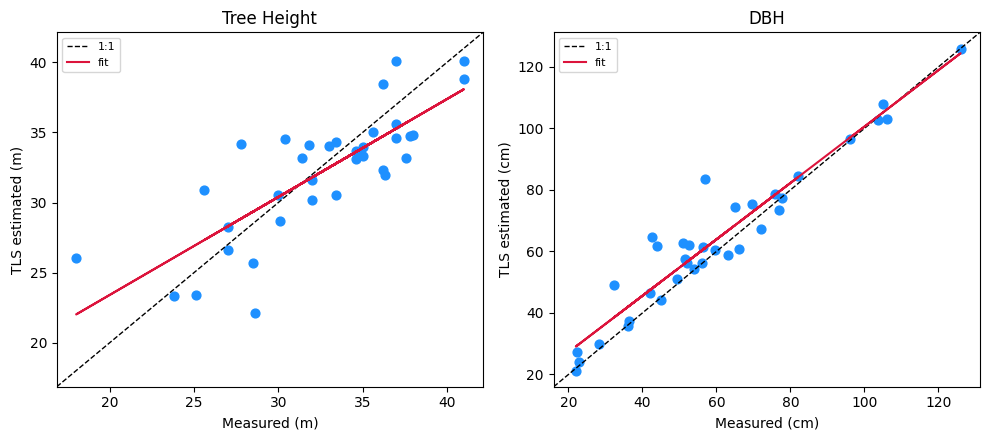

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, act, pred, title, unit in [
        (axes[0], act_h, pred_h, "Tree Height", "m"),
        (axes[1], [tree_dbh[t] for t in ids], pred_dbh, "DBH", "cm")]:
    lo = min(min(act), min(pred)); hi = max(max(act), max(pred))
    pad = 0.05 * (hi - lo)
    ax.scatter(act, pred, s=40, color="dodgerblue")
    lim = (lo - pad, hi + pad)
    ax.plot(lim, lim, "k--", lw=1, label="1:1")
    m, b = np.polyfit(act, pred, 1)
    xs = np.array(act)
    ax.plot(xs, m * xs + b, color="crimson", label="fit")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f"Measured ({unit})"); ax.set_ylabel(f"TLS estimated ({unit})")
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6 · Branch angles per species (authors' `ReCalc_for_Petter.py` logic)
`branch_data_*` columns: branch order, parent, volume, length, angle, height, azimuth, diameter. For the tropical model the **1st-order branch angle is corrected to the horizontal plane** by `90 − angle` (assuming a vertical trunk), while 2nd-order angles are used as-is — exactly as in the paper's Data and methods. Values are summarized as median / 25th / 75th percentiles and fitted with a normal distribution.

**日本語:** `branch_data` から枝角を取り出します。熱帯モデル用の 1 次枝角は `90 − 角度` で水平面基準に補正し、2 次枝角はそのまま使います（論文の手法どおり）。

In [ ]:
BRANCH_COLS = ["branch order", "parent", "volume", "length", "angle", "height", "azimuth", "diameter"]

def branch_angles(ids, order, correct_1st=False):
    out = []
    for t in ids:
        bi = pd.read_csv(f"/content/qsm/branch_data_{t}_noreg.txt", sep="\t", names=BRANCH_COLS)
        ang = list(bi[bi["branch order"] == order]["angle"])
        if correct_1st and order == 1:
            ang = [90 - x for x in ang]
        out.extend(ang)
    return out

species_names = sorted({s for s in set(tree_species.values()) if any(tree_species.get(t) == s for t in guyana_ids)})
sp_ids = {s: [t for t in guyana_ids if tree_species.get(t) == s] for s in species_names}
labels = species_names
ba1 = [branch_angles(sp_ids[s], 1, correct_1st=True) for s in species_names]
ba2 = [branch_angles(sp_ids[s], 2) for s in species_names]

from scipy.stats import norm
for lab, a1, a2 in zip(labels, ba1, ba2):
    mu1, sd1 = norm.fit(a1); mu2, sd2 = norm.fit(a2)
    print(f"{lab:>20}: 1st order n={len(a1):4d} median={np.median(a1):6.1f} 25p={np.percentile(a1,25):6.1f} 75p={np.percentile(a1,75):6.1f} mu={mu1:6.2f} sd={sd1:5.2f}")
    print(f"{'':>20}  2nd order n={len(a2):4d} median={np.median(a2):6.1f} 25p={np.percentile(a2,25):6.1f} 75p={np.percentile(a2,75):6.1f} mu={mu2:6.2f} sd={sd2:5.2f}")

          greenheart: 1st order n= 120 median=  42.3 25p=  10.2 75p=  59.8 mu= 32.20 sd=38.02
                      2nd order n= 320 median=  59.8 25p=  38.6 75p=  81.1 mu= 64.10 sd=35.25
           kabukalli: 1st order n=  44 median=  43.2 25p=  28.1 75p=  57.6 mu= 38.63 sd=25.21
                      2nd order n= 103 median=  54.6 25p=  36.7 75p=  74.3 mu= 56.97 sd=31.29
                mora: 1st order n=  42 median=  39.4 25p=  19.8 75p=  62.5 mu= 37.57 sd=29.80
                      2nd order n=  95 median=  51.2 25p=  33.5 75p=  65.0 mu= 53.36 sd=28.60
           morabukea: 1st order n= 110 median=  44.7 25p=  18.2 75p=  64.9 mu= 39.10 sd=31.10
                      2nd order n= 237 median=  54.6 25p=  39.0 75p=  75.0 mu= 60.64 sd=32.81
        wallaba soft: 1st order n=  53 median=  46.8 25p=  15.6 75p=  57.8 mu= 33.84 sd=35.35
                      2nd order n= 121 median=  48.0 25p=  32.3 75p=  71.8 mu= 56.36 sd=34.26
              wamara: 1st order n=  28 median=  41.2 25p=  1

### 6b · Scots pine (Loobos) branch angles
The Scots pine section of `ReCalc_for_Petter.py` uses branch angles as delivered by TreeQSM (no `90 −` correction) and fits normal distributions. The missing `tree_info_selected_loobos.csv` input/validation split is skipped — all deposited Loobos QSMs are pooled.

**日本語:** スコットパイン（Loobos）の枝角は TreeQSM の角度をそのまま使い、正規分布を当てはめます。入力/検証データ分割用 CSV がないため全木をプールします。

In [ ]:
loobos_ids = sorted(p[len("branch_data_"):-len("_noreg.txt")] for p in MANIFEST
                    if p.startswith("branch_data_TREE"))
ba1_sp = branch_angles(loobos_ids, 1)
ba2_sp = branch_angles(loobos_ids, 2)
mu1_sp, std1_sp = norm.fit(ba1_sp); mu2_sp, std2_sp = norm.fit(ba2_sp)
print(f"Scots pine: 1st order n={len(ba1_sp)} median={np.median(ba1_sp):.1f} 25p={np.percentile(ba1_sp,25):.1f} 75p={np.percentile(ba1_sp,75):.1f} (mu={mu1_sp:.2f}, std={std1_sp:.2f})")
print(f"Scots pine: 2nd order n={len(ba2_sp)} median={np.median(ba2_sp):.1f} 25p={np.percentile(ba2_sp,25):.1f} 75p={np.percentile(ba2_sp,75):.1f} (mu={mu2_sp:.2f}, std={std2_sp:.2f})")

Scots pine: 1st order n=368 median=81.2 25p=62.1 75p=98.8 (mu=81.51, std=29.16)
Scots pine: 2nd order n=292 median=69.3 25p=52.4 75p=89.9 (mu=72.09, std=31.04)


## 7 · Internode lengths from cylinder start coordinates (authors' Equation 1 logic)
Exactly as in `ReCalc_for_Petter.py`: the internode length is the Euclidean distance (×100 → cm) between consecutive **first-cylinder start coordinates** of branches, sorted by height. Trunk internodes use branch-order-1 cylinders; 1st-order-branch internodes use order-2 cylinders grouped by their parent 1st-order branch.

**日本語:** 枝の最初の円柱の始点座標を高さ順に並べ、隣接間のユークリッド距離（×100 cm）を節間長とします。幹は 1 次円柱、1 次枝の節間は 2 次円柱を親枝ごとに扱います。

In [ ]:
from operator import itemgetter
CYL_COLS = ["radius", "length", "start(X)", "start(Y)", "start(Z)", "axis(X)", "axis(Y)", "axis(Z)",
            "parent", "extension", "branch", "branch order", "position in branch", "added", "unmod Radius"]

def internode_lengths_trunk(t):
    ci = pd.read_csv(f"/content/qsm/cyl_data_{t}_noreg.txt", sep="\t", names=CYL_COLS)
    fb = ci[ci["branch order"] == 1]
    n = int(max(fb["branch"]) - min(fb["branch"]))
    coords = []
    for k in range(n + 1):
        c = fb[fb["branch"] == k + 2].iloc[0]
        coords.append((c["start(X)"], c["start(Y)"], c["start(Z)"]))
    coords = sorted(coords, key=itemgetter(2))
    return [100 * math.sqrt((coords[l+1][0]-coords[l][0])**2 + (coords[l+1][1]-coords[l][1])**2 + (coords[l+1][2]-coords[l][2])**2)
            for l in range(n)]

def internode_lengths_1st(t):
    ci = pd.read_csv(f"/content/qsm/cyl_data_{t}_noreg.txt", sep="\t", names=CYL_COLS)
    sb = ci[ci["branch order"] == 2]
    rows = []
    for k in range(len(sb)):
        if int(sb.iloc[k, 12]) == 1:  # first cylinder of a branch
            b = sb.iloc[k]; pc = int(b["parent"])
            pb = int(ci.iloc[pc - 1][10])
            rows.append((b["start(X)"], b["start(Y)"], b["start(Z)"], int(b["branch"]), pb))
    rows = sorted(rows, key=itemgetter(2))
    dfc = pd.DataFrame(rows, columns=["x", "y", "z", "branch", "parent"])
    out = []
    for o in set(dfc["parent"]):
        g = dfc.loc[dfc["parent"] == o]
        for l in range(len(g) - 1):
            a, b2 = g.iloc[l], g.iloc[l + 1]
            out.append(100 * math.sqrt((b2["x"]-a["x"])**2 + (b2["y"]-a["y"])**2 + (b2["z"]-a["z"])**2))
    return out

itr = [sum((internode_lengths_trunk(t) for t in sp_ids[s]), []) for s in species_names]
it1 = [sum((internode_lengths_1st(t) for t in sp_ids[s]), []) for s in species_names]

for lab, tr, o1 in zip(labels, itr, it1):
    print(f"{lab:>20}: trunk internode n={len(tr):4d} median={np.median(tr):6.1f} cm 25p={np.percentile(tr,25):6.1f} 75p={np.percentile(tr,75):6.1f}")
    print(f"{'':>20}  1st-branch internode n={len(o1):4d} median={np.median(o1):6.1f} cm 25p={np.percentile(o1,25):6.1f} 75p={np.percentile(o1,75):6.1f}")

/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as posit

/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as posit

/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as posit

/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as posit

          greenheart: trunk internode n= 110 median=  85.7 cm 25p=  42.5 75p= 166.0
                      1st-branch internode n= 248 median=  85.2 cm 25p=  45.3 75p= 144.4
           kabukalli: trunk internode n=  39 median= 125.5 cm 25p=  70.5 75p= 180.1
                      1st-branch internode n=  74 median= 119.7 cm 25p=  78.0 75p= 198.5
                mora: trunk internode n=  38 median= 112.1 cm 25p=  58.1 75p= 225.6
                      1st-branch internode n=  66 median= 122.5 cm 25p=  69.3 75p= 230.7
           morabukea: trunk internode n= 101 median= 109.3 cm 25p=  43.2 75p= 183.4
                      1st-branch internode n= 171 median= 104.4 cm 25p=  53.0 75p= 186.3
        wallaba soft: trunk internode n=  48 median=  84.0 cm 25p=  38.5 75p= 149.1
                      1st-branch internode n=  93 median=  77.0 cm 25p=  35.9 75p= 154.6
              wamara: trunk internode n=  24 median=  77.3 cm 25p=  42.9 75p= 203.5
                      1st-branch internode n=  36 m

/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])
/tmp/ipykernel_3279/3882231626.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pb = int(ci.iloc[pc - 1][10])


### 7b · Box plots (authors' Figure 7-style summary)
Same four-panel layout as the authors' parameter-summary figure (notebook re-render from the actual computed values).

**日本語:** 著者のサマリー図と同じ 4 パネル構成の箱ひげ図を、本ノートブックで計算した値から再描画します。

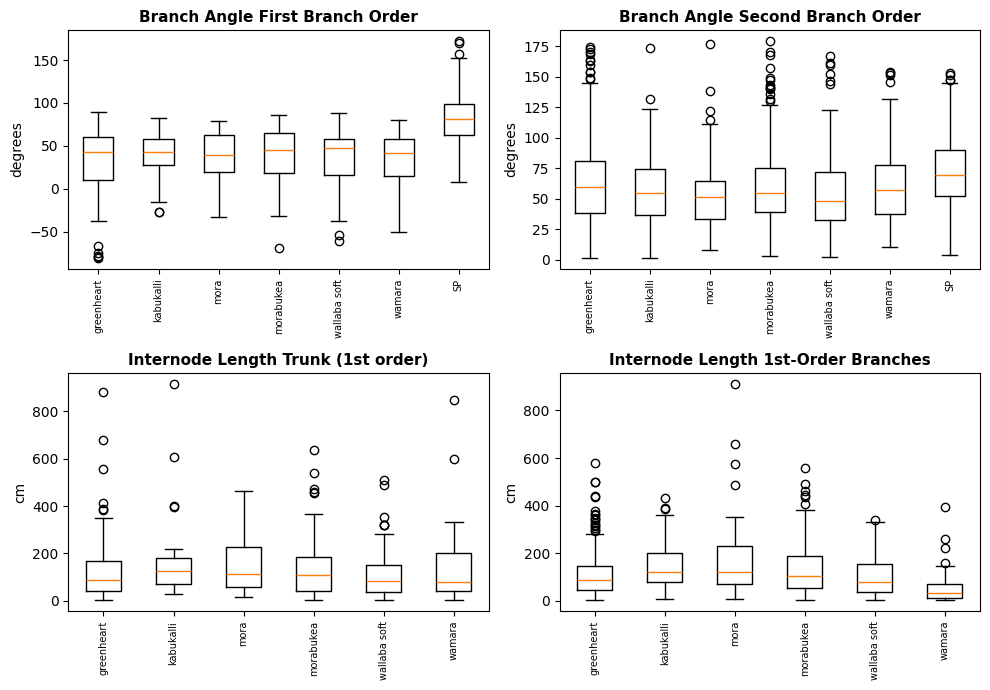

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
panels = [
    (axes[0, 0], ba1 + [ba1_sp], labels + ["SP"], "Branch Angle First Branch Order", "degrees"),
    (axes[0, 1], ba2 + [ba2_sp], labels + ["SP"], "Branch Angle Second Branch Order", "degrees"),
    (axes[1, 0], itr, labels, "Internode Length Trunk (1st order)", "cm"),
    (axes[1, 1], it1, labels, "Internode Length 1st-Order Branches", "cm"),
]
for ax, data, tick, title, ylab in panels:
    ax.boxplot(data, tick_labels=tick)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_ylabel(ylab); ax.tick_params(axis="x", rotation=90, labelsize=7)
plt.tight_layout(); plt.show()

## 8 · Results table and CSV export
Summary of the computed TLS-derived parameters (per species) and the accuracy metrics, exported to `/content/tls_parameters_results.csv`.

**日本語:** 計算したパラメータ要約と精度指標を表にまとめ、CSV に保存します。

In [ ]:
rows = []
for i, lab in enumerate(labels):
    for order, arr in [("branch_angle_1st_deg", ba1[i]), ("branch_angle_2nd_deg", ba2[i]),
                       ("internode_trunk_cm", itr[i]), ("internode_1st_branch_cm", it1[i])]:
        rows.append({"species": lab, "parameter": order, "n": len(arr),
                     "median": np.median(arr), "p25": np.percentile(arr, 25), "p75": np.percentile(arr, 75)})
rows += [
    {"species": "Guyana", "parameter": "height_RMSE_m", "n": len(ids), "median": rmse_h},
    {"species": "Guyana", "parameter": "height_relRMSE_pct", "n": len(ids), "median": rel_h},
    {"species": "Guyana", "parameter": "height_R2", "n": len(ids), "median": r2_h},
    {"species": "Guyana", "parameter": "dbh_RMSE_cm", "n": len(ids), "median": rmse_dbh},
    {"species": "Guyana", "parameter": "dbh_relRMSE_pct", "n": len(ids), "median": rel_dbh},
    {"species": "Guyana", "parameter": "dbh_R2", "n": len(ids), "median": r2_dbh},
]
res = pd.DataFrame(rows)
res.to_csv("/content/tls_parameters_results.csv", index=False)
res

,species,parameter,n,median,p25,p75
0,greenheart,branch_angle_1st_deg,120,42.284000,10.224600,59.775250
1,greenheart,branch_angle_2nd_deg,320,59.773250,38.646925,81.065850
2,greenheart,internode_trunk_cm,110,85.661353,42.547572,165.954459
3,greenheart,internode_1st_branch_cm,248,85.172990,45.319283,144.389541
4,kabukalli,branch_angle_1st_deg,44,43.249200,28.108000,57.627575
5,kabukalli,branch_angle_2nd_deg,103,54.633500,36.736350,74.258700
6,kabukalli,internode_trunk_cm,39,125.476135,70.462941,180.115902
7,kabukalli,internode_1st_branch_cm,74,119.694202,78.015125,198.474383
8,mora,branch_angle_1st_deg,42,39.437850,19.758375,62.476775
9,mora,branch_angle_2nd_deg,95,51.181200,33.477600,64.967250


## 9 · Interpretation and limitations
- The computed height/DBH relative RMSE can be compared with paper Table 4 (tropical trees: height 2.97 %, DBH 17.24 %). Branch-angle and internode RMSE values of Table 4 need CloudCompare-measured comparison tables that are not in the deposit and are **not** recomputed here.
- The derived species-level branch-angle/internode percentiles feed the paper's GroIMP runs (Petter tropical model, LIGNUM Scots pine), which are out of scope of this notebook.
- Limitations: tree→species mapping rebuilt from the field inventory `CommName` column (the authors' `Guyana_tree_species.csv` is not in the deposit); the Loobos input/validation subset split and the paper's t-test on manual corrections are omitted; only archived QSM outputs are used — no point clouds were re-fitted.

**日本語:** 本ノートブックで計算した高さ・DBH の相対 RMSE は論文 Table 4 の値（熱帯樹: 高さ 2.97 %、DBH 17.24 %）と比較できます。Table 4 の枝角・節間長の RMSE は、CloudCompare 実測比較表が公開データに無いため再計算していません。導出した枝角・節間長の要約値は、論文の GroIMP モデル実行（本ノートブック対象外）に入力されるものです。

**References:** Bekkers et al. 2024 (AoB PLANTS plae071); data/script deposit 4TU 10.4121/2b7e832f-12e9-4d0e-92e2-5aef9bcf9142.v1 (CC BY 4.0); TreeQSM output format Raumonen et al. 2013.